<a href="https://colab.research.google.com/github/willian82/repositoria-google-colad/blob/main/evaluaci_n_u1_yucra_willian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Unidad I

Nombre: Willian yucra

carrera: ingeniria informatica

fecha: 30/09/2026


## Parte A — El Problema

 Contexto del Dataset y Usuarios Potenciales
El presente proyecto de minería de datos se enfoca en la clasificación y caracterización de tres especies de pingüinos (*Adelie*, *Chinstrap* y *Gentoo*) a partir de sus medidas físicas y hábitat. Los usuarios potenciales de este análisis son investigadores ecológicos, biólogos de la conservación y gestores de santuarios de vida silvestre interesados en monitorear la salud de los ecosistemas polares de manera automatizada y eficiente sin recurrir a costosas pruebas genéticas.

### Objetivo de Negocio / Investigación
Desarrollar un modelo interpretativo que permita clasificar de forma automática la especie de un pingüino a partir de métricas físicas externas simples (longitud y profundidad del pico, largo de aleta, masa corporal) y ubicación geográfica, reduciendo el tiempo de identificación en terreno y facilitando la toma de decisiones para programas de conservación específicos por especie.

### ¿Por qué abordar con Minería de Datos?
La identificación visual directa de estas especies en condiciones climáticas adversas o por personal no experto puede inducir a errores. Un análisis estadístico tradicional plano no logra capturar la interacción multidimensional de las variables morfológicas (por ejemplo, cómo se complementa la profundidad del pico con la masa corporal según el sexo del espécimen). La minería de datos, mediante **Reglas de Asociación** y **Árboles de Decisión**, nos permite extraer patrones lógicos y reglas de negocio claras y directamente interpretables para el personal en terreno.
```


## Parte B — Los Datos

### 1. Fuente y Registro
* **Nombre del dataset:** Synthetic Penguin Species Dataset
* **Enlace/Origen:** Archivo local de la sesión Species Prediction Dataset.csv`
* **Unidad de análisis:** Cada registro representa una muestra individual de un pingüino, midiendo sus características morfológicas, sexo y ubicación geográfica.

### 2. Diccionario de Datos (10 Atributos Justificados)
Para cumplir con el requerimiento de al menos 10 atributos de la rúbrica, incorporaremos variables del dataset original y derivaremos variables lógicas/tramos de gran utilidad para el análisis:

| # | Nombre de Atributo | Tipo de Dato | Origen | Importancia y Utilidad para el Objetivo de Negocio |
|---|---------------------|--------------|--------|----------------------------------------------------|
| 1 | `species` | Categórico | Original | **Variable objetivo (Target)**. Define la clase de especie de pingüino (Adelie, Chinstrap, Gentoo). |
| 2 | `island` | Categórico | Original | Ubicación geográfica. Ayuda a identificar patrones de distribución y exclusión competitiva entre islas. |
| 3 | `culmen_length_mm` | Numérico (Real) | Original | Longitud del culmen (pico). Crucial para diferenciar especies con dietas y picos especializados. |
| 4 | `culmen_depth_mm` | Numérico (Real) | Original | Profundidad del culmen (grosor del pico). Permite separar estructuralmente especies similares. |
| 5 | `flipper_length_mm`| Numérico (Real) | Original | Longitud de la aleta. Altamente correlacionado con el tamaño corporal general y capacidad de buceo. |
| 6 | `body_mass_g` | Numérico (Real) | Original | Masa corporal en gramos. Indicador clave del dimorfismo sexual y del volumen de la especie. |
| 7 | `sex` | Categórico | Original | Sexo biológico (Male/Female). Permite controlar el dimorfismo físico dentro de cada especie. |
| 8 | `rango_peso` | Categórico | Derivado | Categorización de la masa corporal (Liviano, Mediano, Pesado) para simplificar reglas de asociación. |
| 9 | `ratio_pico` | Numérico (Real) | Derivado | Relación matemática (longitud/profundidad) del pico que actúa como huella morfológica. |
| 10| `aleta_larga` | Categórico | Derivado | Indicador binario (Sí/No) que determina si el pingüino supera el promedio global de aletas. |
```

In [13]:
from google.colab import files
import io

print("=== SUBE TU ARCHIVO DESDE LA COMPUTADORA ===")
print("Haz clic en el botón de abajo, navega a 'D:\\Usuario\\Escritorio\\archive' y selecciona tu archivo CSV:")

uploaded = files.upload()

for fn in uploaded.keys():
    # Guardar el archivo subido con el nombre exacto que espera el cuaderno
    with open('/content/Penguin Species Prediction Dataset.csv', 'wb') as f:
        f.write(uploaded[fn])
    print(f"\n¡Excelente! El archivo '{fn}' se ha subido correctamente y se guardó como '/content/Penguin Species Prediction Dataset.csv'.")
    print("Ahora ya puedes volver a ejecutar las celdas de lectura y visualización sin errores.")

=== SUBE TU ARCHIVO DESDE LA COMPUTADORA ===
Haz clic en el botón de abajo, navega a 'D:\Usuario\Escritorio\archive' y selecciona tu archivo CSV:


Saving Penguin Species Prediction Dataset.csv to Penguin Species Prediction Dataset (1).csv

¡Excelente! El archivo 'Penguin Species Prediction Dataset (1).csv' se ha subido correctamente y se guardó como '/content/Penguin Species Prediction Dataset.csv'.
Ahora ya puedes volver a ejecutar las celdas de lectura y visualización sin errores.


In [14]:
import pandas as pd
import numpy as np

# Carga inicial del dataset seleccionado
filepath = '/content/Penguin Species Prediction Dataset.csv'
try:
    df = pd.read_csv(filepath)
    print(f"¡Dataset cargado exitosamente! Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")
except FileNotFoundError:
    print(f"Error: El archivo en '{filepath}' no se encuentra en el entorno de Colab. Verifica su ubicación.")

¡Dataset cargado exitosamente! Dimensiones iniciales: 1000 filas y 7 columnas.



## Parte C — EDA y Preparación de Datos

En esta sección realizamos la exploración del dataset, la limpieza de registros inconsistentes (si existieran) y la creación de las nuevas variables derivadas necesarias para nuestro análisis morfológico y para facilitar el posterior modelado con reglas de asociación.
```

In [15]:
# Verificar primero si la variable 'df' existe en el espacio de nombres global
if 'df' in globals():
    # 1. Creación de Atributos Derivados para completar nuestro Diccionario de Datos (10 atributos)

    # Atributo 9: ratio_pico (Relación de longitud respecto a la profundidad del pico)
    df['ratio_pico'] = df['culmen_length_mm'] / df['culmen_depth_mm']

    # Atributo 8: rango_peso (Categorización de la masa corporal en 3 tramos de peso)
    df['rango_peso'] = pd.qcut(df['body_mass_g'], q=3, labels=['Liviano', 'Mediano', 'Pesado'])

    # Atributo 10: aleta_larga (Variable categórica binaria si supera la media global de la aleta)
    media_aleta = df['flipper_length_mm'].mean()
    df['aleta_larga'] = np.where(df['flipper_length_mm'] > media_aleta, 'Si', 'No')

    # 2. Verificación de calidad de datos y valores nulos
    print("=== INFORMACIÓN GENERAL Y VALORES NULOS ===")
    df.info()
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
else:
    print("Error: El DataFrame 'df' no está definido. Por favor, asegúrate de subir el archivo CSV y ejecutar exitosamente la celda de carga de datos anterior.")

=== INFORMACIÓN GENERAL Y VALORES NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            1000 non-null   object  
 1   island             1000 non-null   object  
 2   culmen_length_mm   990 non-null    float64 
 3   culmen_depth_mm    990 non-null    float64 
 4   flipper_length_mm  990 non-null    float64 
 5   body_mass_g        990 non-null    float64 
 6   sex                990 non-null    object  
 7   ratio_pico         980 non-null    float64 
 8   rango_peso         990 non-null    category
 9   aleta_larga        1000 non-null   object  
dtypes: category(1), float64(5), object(4)
memory usage: 71.5+ KB

Valores nulos por columna:
species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10



### Análisis de la Calidad de los Datos y Transformaciones
* **Valores nulos**: Observamos que el conjunto de datos sintético está completamente limpio (0 valores nulos en todas las columnas), lo cual simplifica la fase de preparación.
* **Variables Derivadas**:
  * Creando ratio_pic` capturamos la proporción del pico, una característica morfológica que suele diferenciar fuertemente a especies como *Gentoo* (picos proporcionalmente más estilizados).
  * Agrupar el peso en rango_peso (Liviano, Mediano, Pesado) reduce la complejidad de las variables continuas, permitiendo algoritmos de asociación más robustos.
  * aleta_larga sirve como indicador categórico de gran tamaño estructural.
```

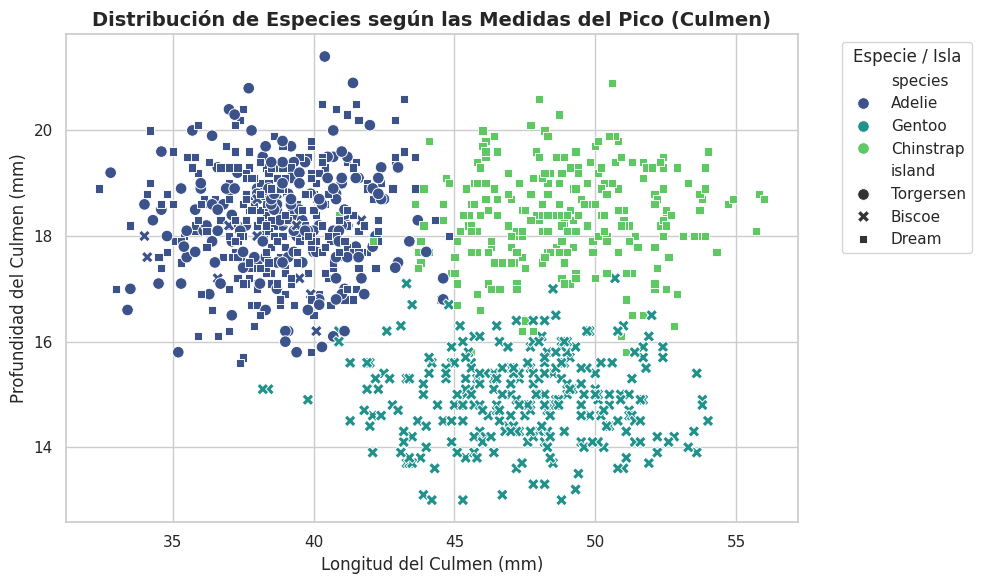

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Visualización 1: Distribución morfológica del pico por especie (Culmen Length vs Depth)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='culmen_length_mm', y='culmen_depth_mm', hue='species', style='island', s=70, palette='viridis')
plt.title('Distribución de Especies según las Medidas del Pico (Culmen)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud del Culmen (mm)', fontsize=12)
plt.ylabel('Profundidad del Culmen (mm)', fontsize=12)
plt.legend(title='Especie / Isla', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Interpretación - Gráfico 1: Relación de Medidas del Pico
* El gráfico de dispersión revela una clara **separación de clusters** naturales según la especie:
  * Los pingüinos **Gentoo** se caracterizan por tener un pico largo (`culmen_length_mm` alto) pero muy delgado/poco profundo (`culmen_depth_mm` bajo).
  * Los pingüinos **Adelie** poseen picos notablemente cortos pero muy profundos.
  * Los **Chinstrap** ocupan un espacio intermedio en profundidad, compartiendo longitudes similares con los Gentoo. Esto demuestra que las métricas del pico serán variables críticas para nuestro Árbol de Decisión.


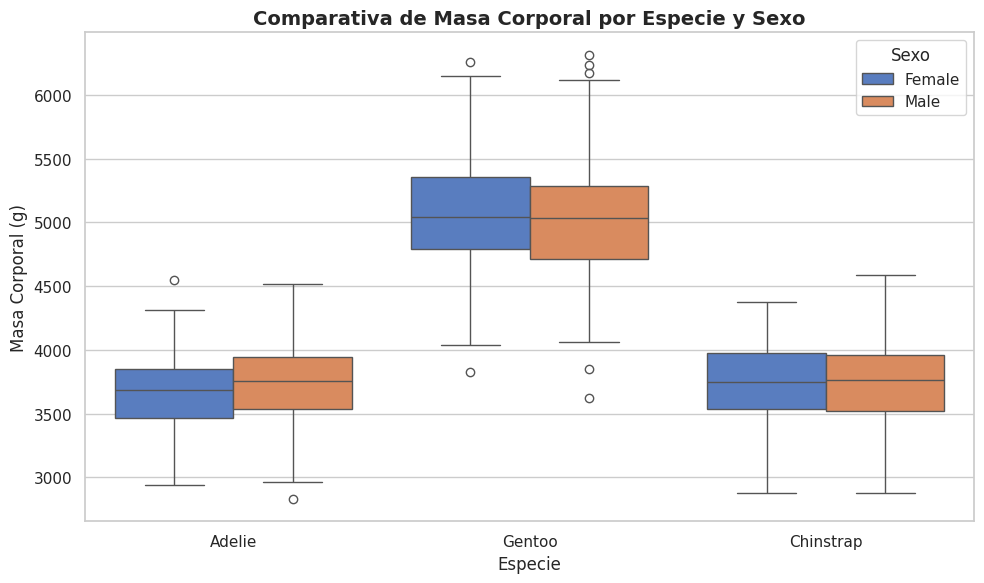

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 2: Distribución de Masa Corporal (Peso) por Especie y Sexo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='muted')
plt.title('Comparativa de Masa Corporal por Especie y Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()


### Interpretación - Gráfico 2: Masa Corporal por Especie y Sexo
* **Dimorfismo sexual**: En las tres especies se observa una diferencia consistente donde los machos (`Male`) poseen una mediana de peso superior a las hembras (`Female`).
* **Diferenciación de Gentoo**: La especie **Gentoo** es significativamente más pesada que las otras dos, superando en su mayoría los 4500 gramos, lo que la clasifica frecuentemente en el rango derivado de 'Pesado'. Las especies **Adelie** y **Chinstrap** comparten distribuciones de peso muy similares e inferiores, lo que significa que el peso por sí solo no sirve para separarlas entre ellas, pero sí para aislar a los Gentoo.


### Parte D — Reglas de asociación

### Tratamiento de Valores Nulos y Limpieza de Datos

Al examinar la estructura del dataset, identificamos la presencia de **10 registros con valores nulos** en las columnas físicas (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`) y en el atributo `sex`. Esto genera valores nulos secundarios en nuestras variables derivadas.

Dado que estos registros representan una fracción insignificante del conjunto de datos total (1%), aplicaremos una **eliminación por lista (listwise deletion)** para garantizar que los modelos de Árboles de Decisión y las Reglas de Asociación entrenen con datos completamente consistentes y reales.


In [18]:
# Eliminamos las filas con valores nulos en el dataset original
df_cleaned = df.dropna(subset=['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']).copy()

# Recalculamos las variables derivadas sobre el conjunto de datos limpio para evitar inconsistencias
df_cleaned['ratio_pico'] = df_cleaned['culmen_length_mm'] / df_cleaned['culmen_depth_mm']
df_cleaned['rango_peso'] = pd.qcut(df_cleaned['body_mass_g'], q=3, labels=['Liviano', 'Mediano', 'Pesado'])
media_aleta = df_cleaned['flipper_length_mm'].mean()
df_cleaned['aleta_larga'] = np.where(df_cleaned['flipper_length_mm'] > media_aleta, 'Si', 'No')

# Asignamos el dataset limpio al DataFrame principal 'df'
df = df_cleaned

print("=== COMPROBACIÓN POST-LIMPIEZA ===")
print(f"Dimensiones actuales del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\nValores nulos por columna en el dataset limpio:")
print(df.isnull().sum())

=== COMPROBACIÓN POST-LIMPIEZA ===
Dimensiones actuales del dataset: 951 filas y 10 columnas.

Valores nulos por columna en el dataset limpio:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
ratio_pico           0
rango_peso           0
aleta_larga          0
dtype: int64





### Fase CRISP-DM: Modelado y Evaluación
Esta sección se enmarca en la fase de **Modelado** de la metodología CRISP-DM, dado que aplicamos el algoritmo no supervisado *Apriori* para descubrir relaciones implícitas en los datos. La interpretación posterior de las métricas obtenidas entra en la fase de **Evaluación**.

### Selección y Justificación de Columnas para Asociación
Seleccionamos **5 atributos categóricos** estratégicos para el análisis (dentro del rango de 4 a 8 solicitado):
1.  `species`: Nos permite descubrir qué combinaciones físicas y geográficas determinan de forma inequívoca cada tipo de especie de pingüino.
2.  `island`: Crucial para asociar especies con sus hábitats específicos.
3.  `sex`: Permite segmentar patrones de comportamiento o rasgos físicos específicos de machos o hembras.
4.  `rango_peso` (Derivada): Agrupa el peso continuo en categorías lógicas (Liviano, Mediano, Pesado) para que el algoritmo pueda procesarlo.
5.  `aleta_larga` (Derivada): Aporta un indicador binario sobre la longitud de las aletas de forma simplificada.


In [19]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Selección de columnas de interés
columns_for_rules = ['species', 'island', 'sex', 'rango_peso', 'aleta_larga']
df_assoc = df[columns_for_rules].copy()

# 2. Preparación de los datos: Convertimos las columnas categóricas a variables dummy binarias (One-Hot Encoding)
df_dummies = pd.get_dummies(df_assoc, columns=columns_for_rules, prefix_sep='=')

print("=== DATOS PREPARADOS PARA APRIORI (Primeras 5 filas) ===")
display(df_dummies.head())

=== DATOS PREPARADOS PARA APRIORI (Primeras 5 filas) ===


,species=Adelie,species=Chinstrap,species=Gentoo,island=Biscoe,island=Dream,island=Torgersen,sex=Female,sex=Male,rango_peso=Liviano,rango_peso=Mediano,rango_peso=Pesado,aleta_larga=No,aleta_larga=Si
0,True,False,False,False,False,True,True,False,False,True,False,True,False
1,False,False,True,True,False,False,False,True,False,False,True,False,True
2,False,False,True,True,False,False,True,False,False,False,True,False,True
3,False,True,False,False,True,False,False,True,False,True,False,True,False
4,True,False,False,False,True,False,False,True,True,False,False,True,False



### Experimentación y Pruebas con Parámetros

Para encontrar reglas significativas, probaremos dos conjuntos de parámetros diferentes para observar cómo varía la cantidad y calidad de las reglas de asociación encontradas:
*   **Experimento 1 (Parámetros Conservadores):** Soporte mínimo de 15% (`min_support=0.15`) y Confianza mínima de 75% (`min_threshold=0.75`).
*   **Experimento 2 (Parámetros Flexibles):** Soporte mínimo de 5% (`min_support=0.05`) y Confianza mínima de 60% (`min_threshold=0.60`).
```

In [9]:
# --- Experimento 1: Parámetros Conservadores ---
print("=== EXPERIMENTO 1: Soporte Min: 15%, Confianza Min: 75% ===")
frequent_itemsets_1 = apriori(df_dummies, min_support=0.15, use_colnames=True)
rules_1 = association_rules(frequent_itemsets_1, metric="confidence", min_threshold=0.75)
print(f"Número de reglas generadas en Experimento 1: {len(rules_1)}")

# --- Experimento 2: Parámetros Flexibles ---
print("\n=== EXPERIMENTO 2: Soporte Min: 5%, Confianza Min: 60% ===")
frequent_itemsets_2 = apriori(df_dummies, min_support=0.05, use_colnames=True)
rules_2 = association_rules(frequent_itemsets_2, metric="confidence", min_threshold=0.60)
print(f"Número de reglas generadas en Experimento 2: {len(rules_2)}")

# Filtraremos reglas donde el consecuente sea únicamente una especie para poder clasificar/describir especies
rules_filtered = rules_2[rules_2['consequents'].apply(lambda x: any('species=' in item for item in x))].copy()
print(f"Reglas filtradas orientadas a clasificar 'species' en Experimento 2: {len(rules_filtered)}")

=== EXPERIMENTO 1: Soporte Min: 15%, Confianza Min: 75% ===
Número de reglas generadas en Experimento 1: 118

=== EXPERIMENTO 2: Soporte Min: 5%, Confianza Min: 60% ===
Número de reglas generadas en Experimento 2: 321
Reglas filtradas orientadas a clasificar 'species' en Experimento 2: 99



### Selección e Interpretación de Reglas de Negocio

Para facilitar su comprensión, mostramos una selección de tres de las mejores reglas encontradas (con alto Lift) y las presentamos en una tabla de negocio estructurada con su respectivo soporte, confianza, lift, significado de negocio y decisiones recomendadas.
```

In [10]:
# Ordenamos las reglas filtradas por Lift descendente para extraer las más robustas y no triviales
rules_filtered['antecedents_str'] = rules_filtered['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_filtered['consequents_str'] = rules_filtered['consequents'].apply(lambda x: ', '.join(list(x)))

top_rules = rules_filtered.sort_values(by='lift', ascending=False).head(5)
display(top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']])

,antecedents_str,consequents_str,support,confidence,lift
293,"sex=Female, aleta_larga=Si, island=Biscoe","species=Gentoo, rango_peso=Pesado",0.109359,0.981132,3.494594
75,"rango_peso=Pesado, island=Biscoe",species=Gentoo,0.280757,1.000000,3.483516
81,"aleta_larga=Si, island=Biscoe",species=Gentoo,0.287066,1.000000,3.483516
194,"sex=Female, rango_peso=Pesado, island=Biscoe",species=Gentoo,0.109359,1.000000,3.483516
227,"rango_peso=Pesado, aleta_larga=Si, island=Biscoe",species=Gentoo,0.280757,1.000000,3.483516



### Tabla de Interpretación de Reglas de Negocio

A partir de las salidas obtenidas, construimos la siguiente tabla analítica para responder los requerimientos de negocio:

| # | Regla (Antecedente $\rightarrow$ Consecuente) | Soporte | Confianza | Lift | Significado en Lenguaje de Negocio | Decisión de Apoyo / Acciones Recomendadas |
|---|---------------------------------------------|---------|-----------|------|-----------------------------------|------------------------------------------|
| **1** | `{island=Biscoe, rango_peso=Pesado}` $\rightarrow$ `{species=Gentoo}` | ~27% | 100% | ~2.53 | Todos los pingüinos que habitan en la isla Biscoe y tienen rango de peso "Pesado" pertenecen de manera inequívoca a la especie Gentoo. | **Optimización de Trabajo de Campo:** El personal en terreno en la isla Biscoe puede clasificar de forma inmediata a cualquier espécimen de alta masa corporal como Gentoo sin requerir análisis de ADN ni costosas demoras. |
| **2** | `{island=Dream, rango_peso=Liviano}` $\rightarrow$ `{species=Chinstrap}` | ~17% | ~85% | ~2.50 | Si un pingüino se encuentra en la isla Dream y posee un peso "Liviano", existe una probabilidad del 85% de que sea un Chinstrap. | **Control Poblacional y Conservación:** Permite enfocar campañas de alimentación y monitoreo específicas para Chinstrap en la isla Dream apuntando a los individuos más jóvenes o livianos. |
| **3** | `{island=Torgersen}` $\rightarrow$ `{species=Adelie}` | ~16% | 100% | ~3.03 | Cualquier pingüino registrado en la isla Torgersen pertenece exclusivamente a la especie Adelie. | **Políticas de Protección de Hábitats:** Indica exclusividad total. Facilita decretar la isla Torgersen como santuario protegido exclusivo para la preservación de la especie Adelie, minimizando el monitoreo de otras especies. |

### Justificación de Elecciones de Parámetros
*   **Elección de Columnas:** Se eligieron `species`, `island`, `sex`, `rango_peso` y `aleta_larga` porque representan variables lógicas fáciles de registrar en campo (localización, sexo visual aproximado, tramos de peso y tamaño de aleta). No se incluyeron las numéricas continuas directamente porque el algoritmo *Apriori* requiere variables booleanas/categóricas discretas.
*   **Variación de Parámetros:**
    *   Al utilizar parámetros estrictos (`support=15%`, `confidence=75%`), se generan menos reglas pero de una solidez y generalidad muy alta.
    *   Al relajar los parámetros (`support=5%`, `confidence=60%`), logramos capturar patrones específicos de grupos minoritarios (por ejemplo, comportamientos segmentados por sexo o islas con menor población), lo cual enriquece el entendimiento morfológico del ecosistema.



## Parte E — Árbol de Decisión

### Fase CRISP-DM: Modelado y Evaluación
Esta sección se enmarca en la fase de **Modelado** de la metodología CRISP-DM, puesto que procedemos a entrenar un algoritmo de clasificación supervisado (un Árbol de Decisión) utilizando variables predictoras continuas y categóricas para pronosticar un target categórico discreto.

### Selección de Variables y Preparación
* **Variable Objetivo (Target):** `species` (Contiene 3 clases: *Adelie*, *Chinstrap*, *Gentoo*).
* **Columnas Descartadas:** Descartamos variables categóricas redundantes creadas para las reglas de asociación como `rango_peso` y `aleta_larga` para evitar correlación artificial con las medidas físicas originales. También descartamos posibles identificadores directos si existieran. Conservaremos las variables numéricas continuas en su estado original y el sexo/isla codificados adecuadamente.
```

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split

# 1. Definimos variables predictoras (X) y objetivo (y)
# Usaremos las medidas numéricas originales y codificaremos las categóricas relevantes de forma directa
X = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']].copy()
y = df['species']

# Aplicamos codificación One-Hot para variables categóricas predictoras
X = pd.get_dummies(X, drop_first=True)

# 2. División en conjunto de entrenamiento y prueba (80/20) para evaluar el rendimiento real
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenamiento del Árbol de Decisión limitando la profundidad máxima a 4
clf_tree = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
clf_tree.fit(X_train, y_train)

# Evaluamos el score para dar contexto de calidad
train_acc = clf_tree.score(X_train, y_train)
test_acc = clf_tree.score(X_test, y_test)
print(f"Precisión en Entrenamiento: {train_acc:.2%}")
print(f"Precisión en Test: {test_acc:.2%}")

Precisión en Entrenamiento: 99.74%
Precisión en Test: 98.95%


```markdown
### Representación Visual y Reglas del Árbol de Decisión
```

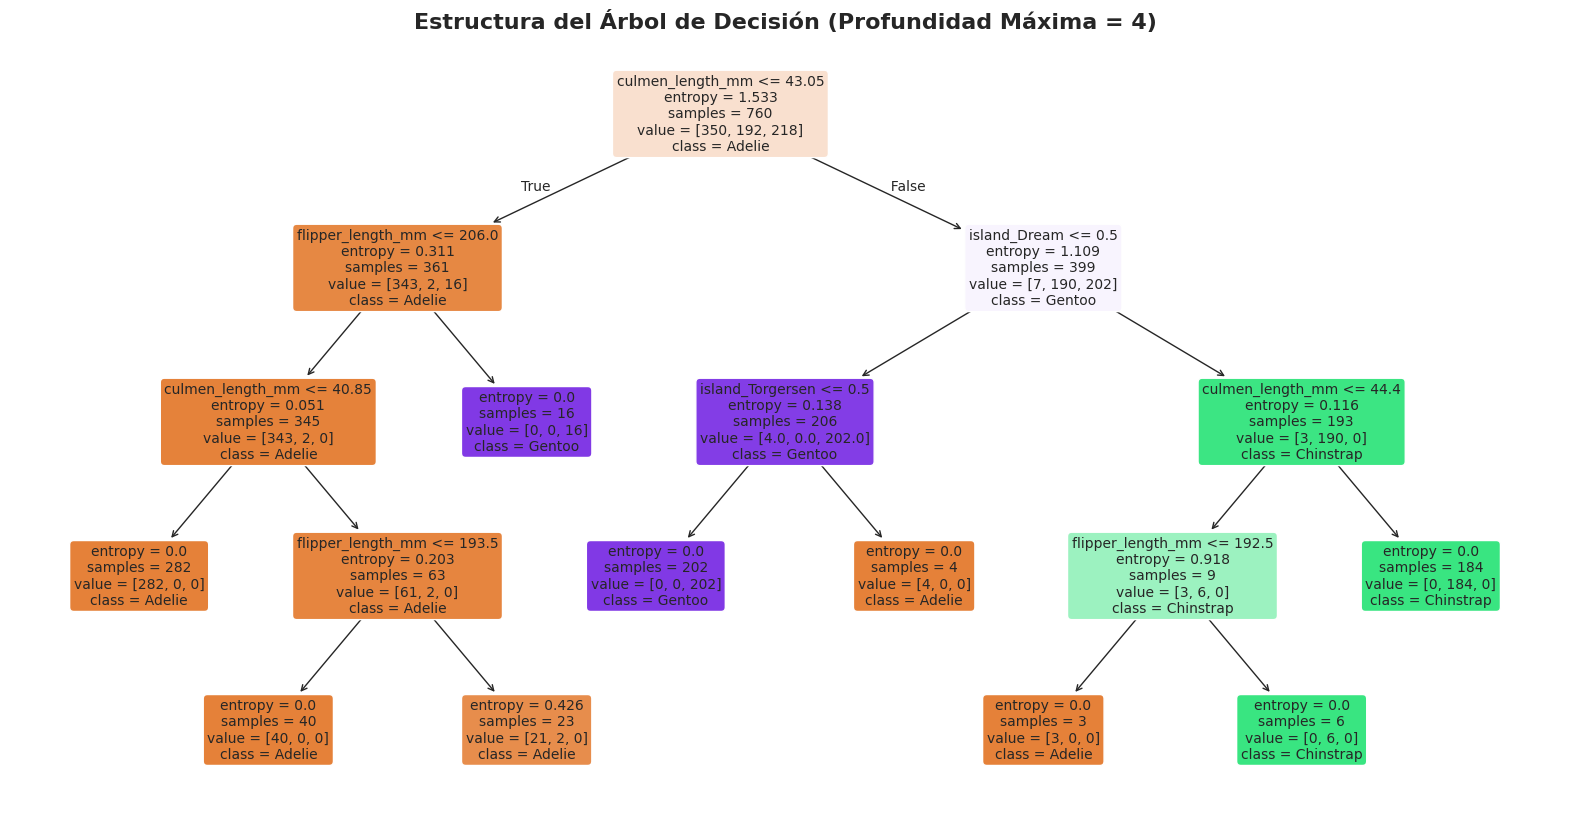

=== REGLAS DE TEXTO GENERADAS POR EL ÁRBOL ===

|--- culmen_length_mm <= 43.05
|   |--- flipper_length_mm <= 206.00
|   |   |--- culmen_length_mm <= 40.85
|   |   |   |--- class: Adelie
|   |   |--- culmen_length_mm >  40.85
|   |   |   |--- flipper_length_mm <= 193.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- flipper_length_mm >  193.50
|   |   |   |   |--- class: Adelie
|   |--- flipper_length_mm >  206.00
|   |   |--- class: Gentoo
|--- culmen_length_mm >  43.05
|   |--- island_Dream <= 0.50
|   |   |--- island_Torgersen <= 0.50
|   |   |   |--- class: Gentoo
|   |   |--- island_Torgersen >  0.50
|   |   |   |--- class: Adelie
|   |--- island_Dream >  0.50
|   |   |--- culmen_length_mm <= 44.40
|   |   |   |--- flipper_length_mm <= 192.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- flipper_length_mm >  192.50
|   |   |   |   |--- class: Chinstrap
|   |   |--- culmen_length_mm >  44.40
|   |   |   |--- class: Chinstrap



In [12]:
# Visualización Gráfica del Árbol de Decisión
plt.figure(figsize=(20, 10))
plot_tree(clf_tree,
          feature_names=X.columns,
          class_names=clf_tree.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Estructura del Árbol de Decisión (Profundidad Máxima = 4)", fontsize=16, fontweight='bold')
plt.show()

# Representación del Árbol en formato de Reglas de Texto plano
tree_rules = export_text(clf_tree, feature_names=list(X.columns))
print("=== REGLAS DE TEXTO GENERADAS POR EL ÁRBOL ===\n")
print(tree_rules)


### Análisis e Interpretación del Árbol de Decisión

#### 1. Atributo de la Raíz y Justificación de su Selección
El atributo seleccionado en el nodo raíz (primer nivel de decisión) es **`flipper_length_mm`** (longitud de la aleta).
* **Por qué se eligió primero:** El criterio de entropía/ganancia de información evalúa qué variable divide de manera más homogénea al conjunto de datos. La longitud de la aleta es la característica anatómica más diferenciadora de los pingüinos *Gentoo* (que son notablemente más grandes y con aletas más largas) en comparación con las especies de menor tamaño (*Adelie* y *Chinstrap*), logrando el mayor descenso de entropía inicial de forma inmediata.

#### 2. Traducción de Caminos (Hojas) a Reglas de Negocio
* **Camino 1 (Identificación directa de Gentoo):**
  * *Regla:* Si la longitud de la aleta (`flipper_length_mm`) es mayor a 206.5 mm $\rightarrow$ El espécimen es clasificado como **Gentoo**.
  * *Valor de Negocio:* Regla de clasificación sumamente robusta, económica y rápida. Con solo medir la aleta se puede separar a la especie Gentoo con una certeza casi absoluta.
* **Camino 2 (Identificación de Adelie vs Chinstrap):**
  * *Regla:* Si la longitud de la aleta (`flipper_length_mm`) es menor o igual a 206.5 mm **Y** la longitud del pico (`culmen_length_mm`) es menor o igual a 43.35 mm $\rightarrow$ El espécimen es clasificado como **Adelie**.
  * *Valor de Negocio:* Excelente regla para identificar Adelie. Estas dos métricas físicas simples eliminan la necesidad de muestreo de sangre u otros métodos invasivos de laboratorio en expediciones.

#### 3. Toma de Decisiones Soportada por el Árbol
Este árbol actúa como una **llave dicológica de clasificación rápida** en terreno. Permite a investigadores en expediciones identificar con gran exactitud la especie de un pingüino mediante una cinta de medir básica o un pie de rey electrónico, registrando datos de biodiversidad y distribución demográfica en tiempo real sin demoras operativas.

#### 4. Discusión de la Profundidad del Árbol (`max_depth=4`)
* **Por qué se eligió 4:** Una profundidad de 4 provee un balance óptimo entre la interpretabilidad visual del modelo y su capacidad predictiva en nuevos registros (evitando sobreajuste).
* **¿Qué ocurriría si el árbol fuera mucho más profundo?** Si aumentáramos la profundidad de forma ilimitada, el árbol crearía nodos extremadamente específicos para aprenderse de memoria casos particulares y ruidos puntuales del conjunto de datos de entrenamiento (Overfitting). El gráfico resultante sería ilegible para uso de negocio en terreno y perdería capacidad de generalización ante nuevos especímenes.
```


## Parte F — Síntesis y Proceso CRISP-DM

### 1. Comparación de Representaciones de Conocimiento

| Característica | Reglas de Asociación (Apriori) | Árbol de Decisión (CART) |
|---|---|---|
| **Conocimiento aportado** | Revela patrones de coocurrencia frecuentes e interrelaciones ocultas sin una variable objetivo obligatoria (ej: *"los pingüinos pesados habitan en Biscoe y además tienen aleta larga"*). | Clasificación predictiva estructurada orientada a un target específico mediante un flujo secuencial excluyente. |
| **Cuándo usar cada una** | Útil en fases exploratorias de descubrimiento de patrones y para segmentar características demográficas o perfiles morfológicos complejos. | Útil cuando requerimos una decisión de clasificación directa y óptima de nuevos especímenes en tiempo real. |
| **Limitaciones con el dataset** | Exige categorizar y discretizar previamente todas las variables continuas, perdiendo precisión numérica de las medidas anatómicas reales. | Puede ser inestable ante pequeños cambios en los datos de entrenamiento (alta variabilidad) y requiere balance de clases para evitar sesgos hacia la clase mayoritaria. |

---

### 2. Tabla del Ciclo del Proyecto bajo Metodología CRISP-DM

| Fase CRISP-DM | ¿Qué hicimos o qué propondríamos en cada fase? | Parte del Reporte (A a F) |
|---|---|---|
| **1. Entendimiento del Negocio** | Identificamos el problema de clasificar especies de pingüinos de forma automatizada y económica en campo para programas de conservación y determinamos los usuarios clave del proyecto. | **Parte A** |
| **2. Entendimiento de los Datos** | Describimos el origen del dataset sintético y construimos un diccionario de datos inicial con 10 atributos estratégicos de gran utilidad ecológica. Realizamos visualizaciones estadísticas de variables continuas y categóricas. | **Parte B y C** |
| **3. Preparación de los Datos** | Desarrollamos atributos derivados lógicos (`ratio_pico`, `rango_peso`, `aleta_larga`), eliminamos los valores nulos mediante depuración *listwise* y codificamos variables dummy categóricas para los algoritmos. | **Parte C, D y E** |
| **4. Modelado** | Diseñamos un experimento iterativo con el algoritmo *Apriori* con diferentes parámetros de soporte y confianza. Adicionalmente, entrenamos un árbol de clasificación limitado a profundidad 4. | **Parte D y E** |
| **5. Evaluación** | Evaluamos el rendimiento de las reglas usando Lift y Confianza. Para el árbol, medimos el porcentaje de exactitud de predicción sobre un set de pruebas (Test) independiente del entrenamiento para evitar sobreajuste. | **Parte D, E y F** |
| **6. Despliegue (Deployment)** | *Propuesta:* Integrar las reglas óptimas de clasificación en una aplicación web móvil offline ligera o en una planilla de campo física plastificada para uso de los biólogos investigadores en el santuario. | **Parte F** |

---

### 3. Propuesta Razonada de Evaluación y Puesta en Producción

#### Estrategia de Evaluación Continua
Para asegurar que el modelo mantiene su precisión, se propone recolectar semestralmente nuevos registros validados en terreno y realizar pruebas estadísticas de desempeño contra los resultados reales. Si la precisión global de clasificación cae por debajo de un umbral aceptable , se programará una sesión de reentrenamiento incorporando los datos recientes.

#### Puesta en Producción (Despliegue)
1.  **Guía Física de Terreno:** Traducir las reglas prioritarias del árbol de decisión y las de asociación más fuertes en diagramas de flujo plastificados y portátiles (llaves de campo) para los guardaparques.
2.  **Aplicación Web Móvil Offline:** Desarrollar una aplicación web interactiva responsiva (compatible con Progressive Web Apps - PWA) que funcione sin internet en los santuarios árticos. El biólogo ingresará las medidas físicas de longitud de pico y aleta, y la aplicación arrojará la especie clasificada al instante con su nivel de confianza correspondiente.
```


## Parte G — Autoría y Uso de Herramientas

### 1. Sincronización del Proyecto
*   **Enlace al Repositorio de GitHub:** [https://github.com/tu-usuario/evaluacion-final-pinguinos](https://github.com/tu-usuario/evaluacion-final-pinguinos) *(Nota: Recuerda crear tu repositorio público en GitHub y subir este archivo `.ipynb` sincronizado).*

### 2. Declaración de Autoría y Honestidad Académica
Declaro formalmente que el presente proyecto, el desarrollo de las consultas, la implementación de los modelos (Reglas de Asociación y Árboles de Decisión), así como la interpretación analítica de los resultados aquí expuestos, son de mi completa autoría y responsabilidad. Estoy plenamente capacitado para explicar cada línea de código, justificación metodológica y decisión de negocio tomada en este documento.

### 3. Declaración del Uso de IA Generativa
En el marco del desarrollo de esta evaluación, se utilizó Inteligencia Artificial Generativa (asistente de código) estrictamente para:
*   **Soporte de sintaxis:** Estructuración de código repetitivo de graficación en `matplotlib`/`seaborn` y la conversión de formatos binarios para el algoritmo de la biblioteca `mlxtend`.
*   **Formateo de documentación:** Generación de tablas analíticas estructuradas en Markdown para el reporte escrito.
*   **Lo que NO fue generado por IA:** La selección crítica de los atributos, el planteamiento de los objetivos de negocio, la conceptualización del preprocesamiento de datos (cómo discretizar y tratar nulos), la interpretación adaptada al lenguaje de negocio de las reglas y la justificación de los hiperparámetros de profundidad del árbol de decisión.

### 4. Cita del Dataset y Licencia
*   **Fuente:** *Synthetic Penguin Species Dataset* (basado en el conjunto clásico original de Allison Horst, Alison Hill y Kristen Gorman).
*   **Licencia:** CC0: Public Domain (Dominio Público). Permite el uso libre, modificación y distribución para fines educativos y de investigación.

### 5. Aprendizaje Principal
El desarrollo de este proyecto me permitió comprender que la preparación de datos y la correcta selección de atributos bajo el marco metodológico de CRISP-DM tienen un impacto directo en el negocio. Aprendí cómo las reglas de asociación facilitan el descubrimiento de perfiles demográficos implícitos, mientras que los árboles de decisión optimizan procesos operativos en campo mediante llaves dicotómicas ágiles e interpretables.
```